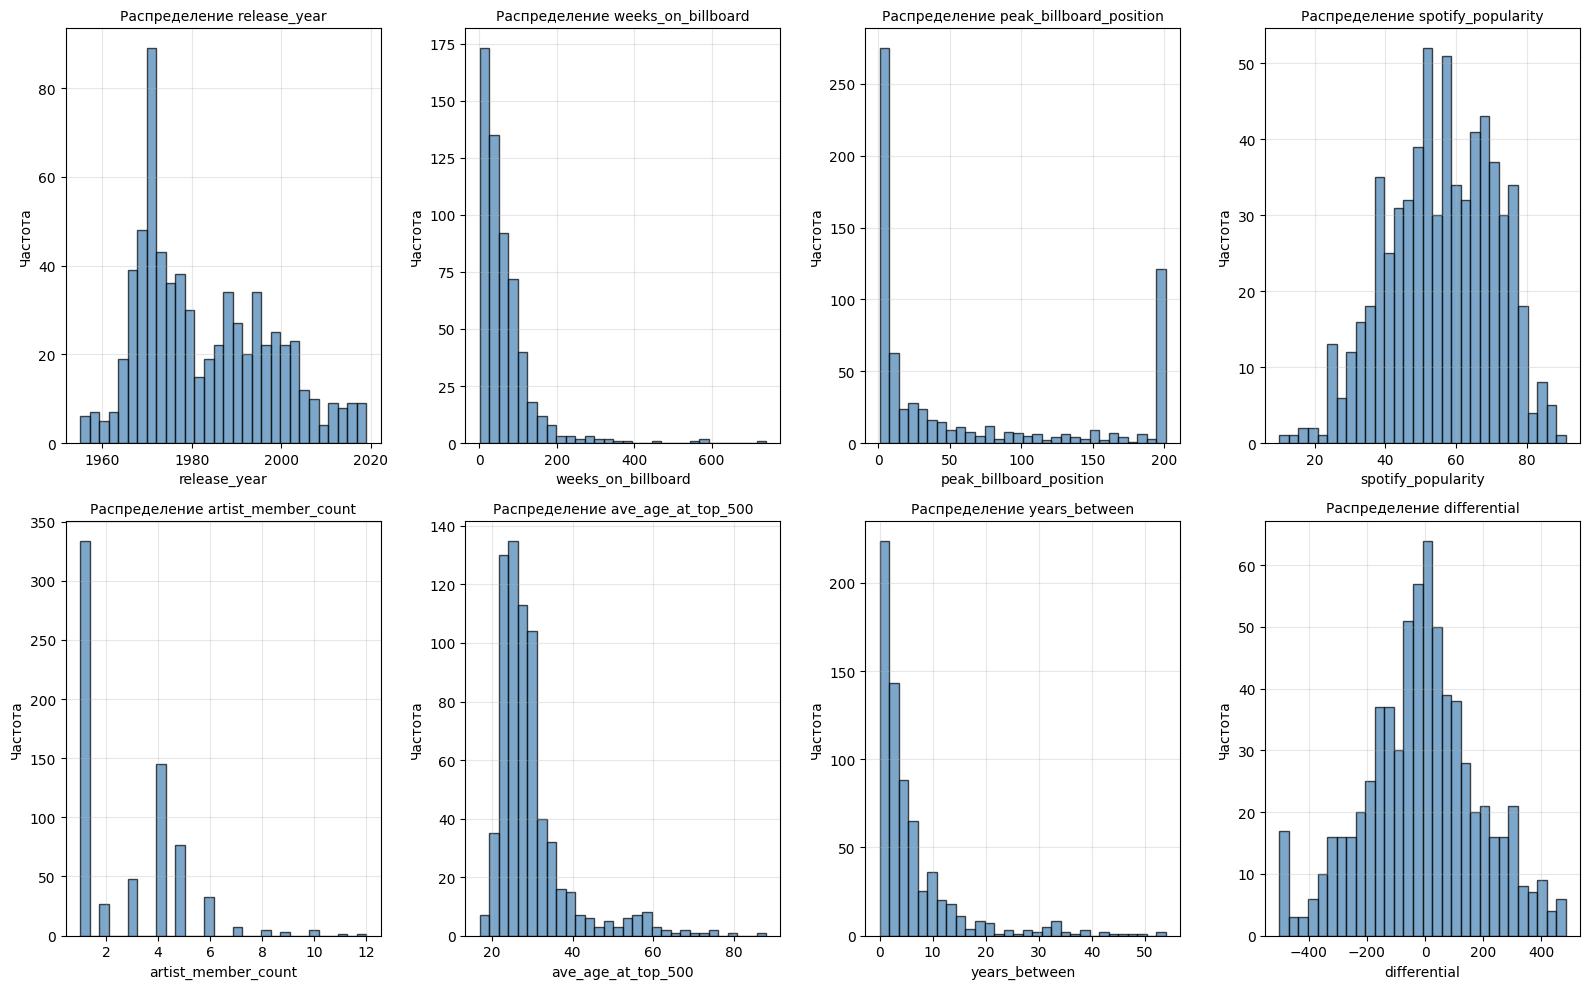

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#1.2.1
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-07/rolling_stone.csv'
df = pd.read_csv(url)
numeric_features = ['release_year', 'weeks_on_billboard', 'peak_billboard_position',
                    'spotify_popularity', 'artist_member_count', 'ave_age_at_top_500',
                    'years_between', 'differential']
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Распределение {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

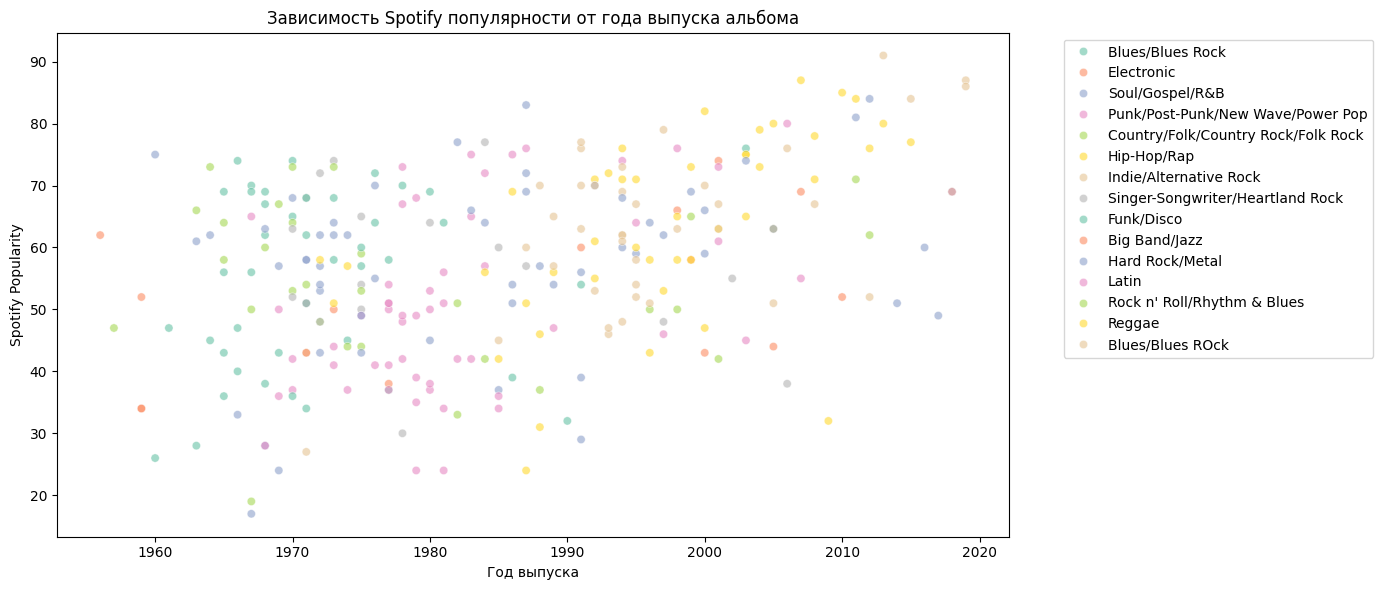

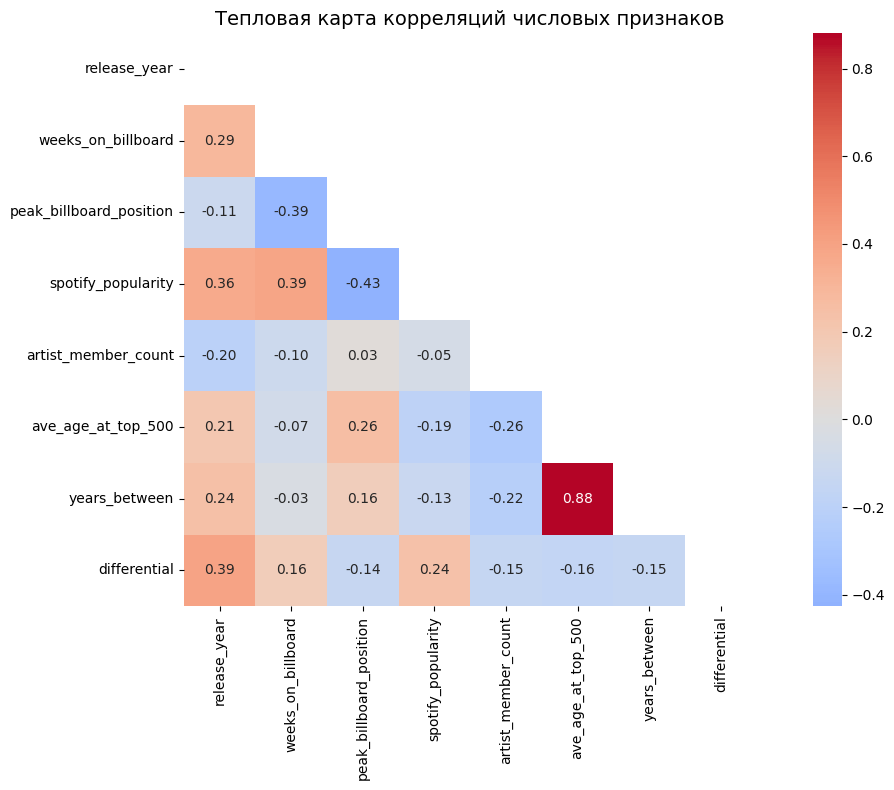

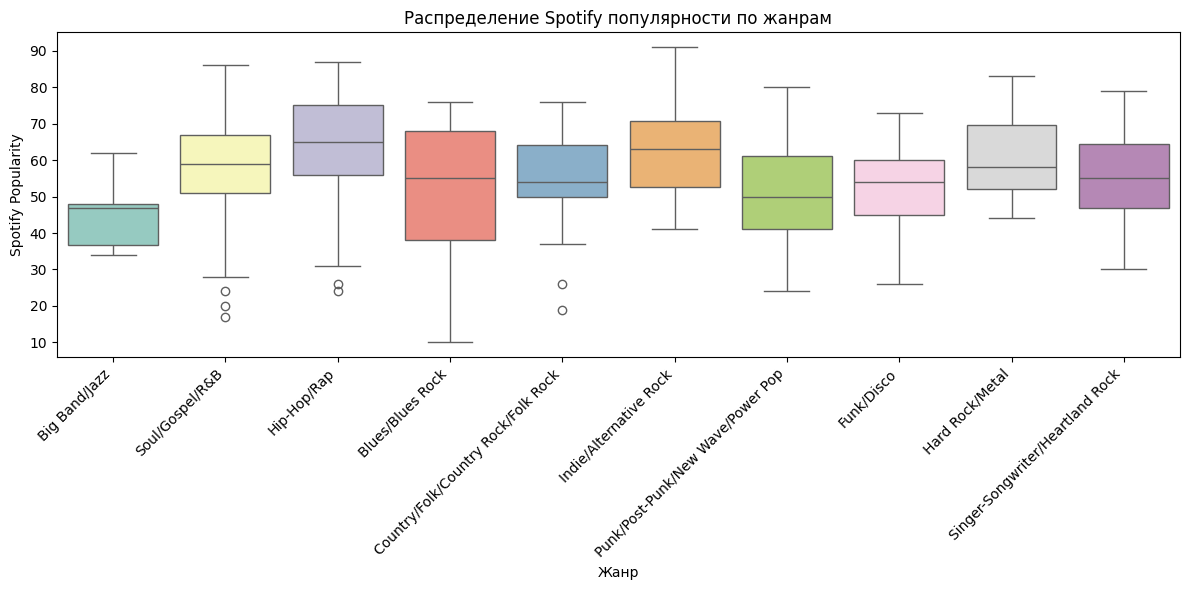

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
#1.2.2
df_clean = df.dropna(subset=['spotify_popularity', 'genre'])
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_clean.sample(300), x='release_year', y='spotify_popularity',
                hue='genre', alpha=0.6, palette='Set2')
plt.title('Зависимость Spotify популярности от года выпуска альбома')
plt.xlabel('Год выпуска')
plt.ylabel('Spotify Popularity')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
numeric_features = ['release_year', 'weeks_on_billboard', 'peak_billboard_position',
                    'spotify_popularity', 'artist_member_count', 'ave_age_at_top_500',
                    'years_between', 'differential']

plt.figure(figsize=(12, 8))
corr_matrix = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Тепловая карта корреляций числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()
top_genres = df_clean['genre'].value_counts().head(10).index
df_top = df_clean[df_clean['genre'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='genre', y='spotify_popularity', hue='genre', legend=False, palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Распределение Spotify популярности по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Spotify Popularity')
plt.tight_layout()
plt.show()

In [39]:
import plotly.express as px
import plotly.graph_objects as go
#1.2.3
df_plot = df.dropna(subset=['rank_2020', 'release_year', 'genre', 'spotify_popularity'])
fig = px.scatter(df_plot,
                 x='release_year',
                 y='rank_2020',
                 hover_data=['album', 'clean_name'],
                 color='genre',
                 title='Рейтинг 2020 vs Год выпуска альбома',
                 labels={'rank_2020': 'Рейтинг 2020 (меньше = лучше)',
                         'release_year': 'Год выпуска'})
fig.update_layout(yaxis=dict(autorange='reversed'))
fig.show()
df['decade'] = (df['release_year'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()

fig2 = px.bar(x=decade_counts.index, y=decade_counts.values,
             title='Количество альбомов в топ-500 по десятилетиям',
             labels={'x': 'Десятилетие', 'y': 'Количество альбомов'},
             color=decade_counts.values, color_continuous_scale='Viridis')
fig2.show()
fig3 = px.scatter(df_plot,
                 x='release_year',
                 y='spotify_popularity',
                 hover_data=['album', 'clean_name', 'genre'],
                 color='genre',
                 title='Spotify популярность vs Год выпуска альбома',
                 labels={'spotify_popularity': 'Spotify Popularity',
                         'release_year': 'Год выпуска'})
fig3.show()

In [40]:
print("Пропущенные значения до обработки:")
print(df.isnull().sum())
#1.2.4
print(f"\nПропуски в spotify_popularity до обработки: {df['spotify_popularity'].isnull().sum()}")
df['spotify_popularity'] = df.groupby('genre')['spotify_popularity'].transform(
    lambda x: x.fillna(x.median())
)
df_clean = df.dropna(subset=['genre', 'release_year'])
print(f"Удалено строк с пропущенными genre/release_year: {len(df) - len(df_clean)}")
for col in ['weeks_on_billboard', 'peak_billboard_position']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col}: заполнено пропусков медианой ({median_val})")

Пропущенные значения до обработки:
sort_name                     0
clean_name                    0
album                         0
rank_2003                   191
rank_2012                   191
rank_2020                   191
differential                  0
release_year                  0
genre                       164
type                          0
weeks_on_billboard          119
peak_billboard_position       0
spotify_popularity           37
spotify_url                  36
artist_member_count           5
artist_gender                 5
artist_birth_year_sum         5
debut_album_release_year      5
ave_age_at_top_500            5
years_between                 5
album_id                      0
decade                        0
dtype: int64

Пропуски в spotify_popularity до обработки: 37
Удалено строк с пропущенными genre/release_year: 164
weeks_on_billboard: заполнено пропусков медианой (46.5)
peak_billboard_position: заполнено пропусков медианой (16.0)


/tmp/ipykernel_3580/3368393515.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



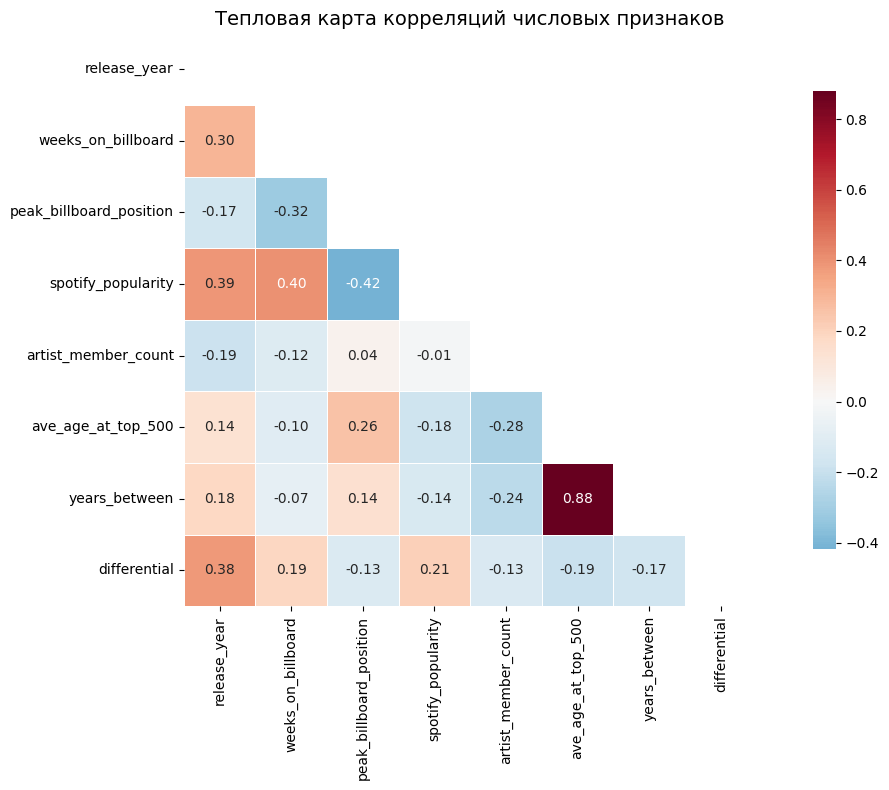

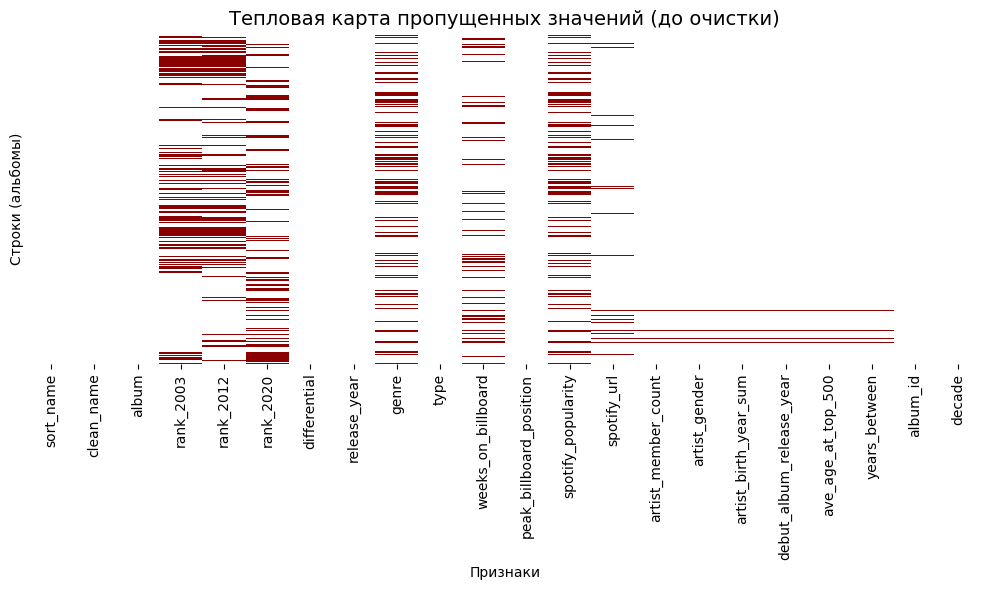

In [41]:
#1.2.5
plt.figure(figsize=(12, 8))
corr_matrix = df_clean[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Тепловая карта корреляций числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
            cmap=['white', 'darkred'])
plt.title('Тепловая карта пропущенных значений (до очистки)', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Строки (альбомы)')
plt.tight_layout()
plt.show()

In [42]:
initial_count = len(df_clean)
#1.2.6
df_clean = df_clean.drop_duplicates(subset=['album', 'clean_name'])
print(f"Удалено дубликатов: {initial_count - len(df_clean)}")
duplicates_by_year = df_clean.groupby(['album', 'clean_name'])['release_year'].nunique()
problem_albums = duplicates_by_year[duplicates_by_year > 1]
if len(problem_albums) > 0:
    print(f"Найдено альбомов с противоречивыми годами: {len(problem_albums)}")

Удалено дубликатов: 0


weeks_on_billboard       :  31 выбросов (5.9%)
peak_billboard_position  :   0 выбросов (0.0%)
artist_member_count      :   9 выбросов (1.7%)
years_between            :  41 выбросов (7.8%)


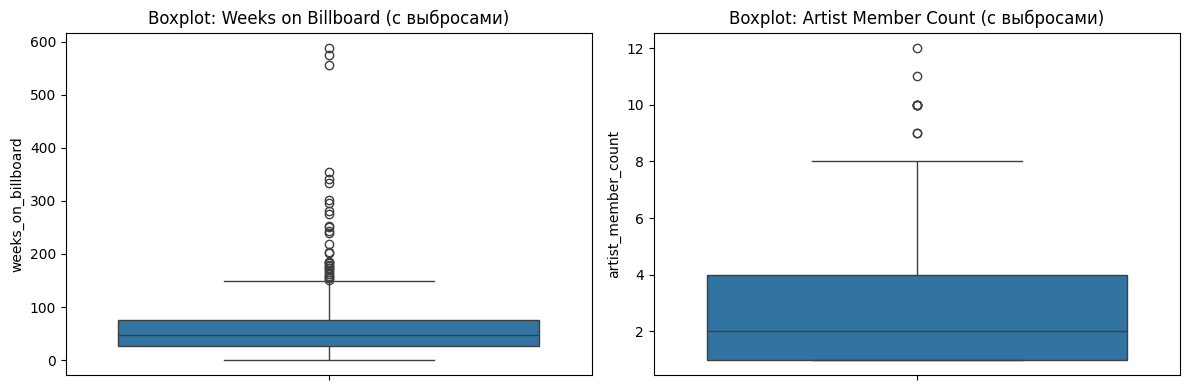

In [43]:
#1.2.7
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound
outliers_summary = {}
for col in ['weeks_on_billboard', 'peak_billboard_position', 'artist_member_count', 'years_between']:
    n_outliers, lb, ub = detect_outliers_iqr(df_clean, col)
    outliers_summary[col] = n_outliers
    print(f"{col:25s}: {n_outliers:3d} выбросов ({n_outliers/len(df_clean)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_clean, y='weeks_on_billboard', ax=axes[0])
axes[0].set_title('Boxplot: Weeks on Billboard (с выбросами)')

sns.boxplot(data=df_clean, y='artist_member_count', ax=axes[1])
axes[1].set_title('Boxplot: Artist Member Count (с выбросами)')

plt.tight_layout()
plt.show()

In [44]:
#1.2.8
df_clean = df_clean.reset_index(drop=True)
top_albums = df_clean[(df_clean['rank_2020'] <= 50) & (df_clean['spotify_popularity'] > 80)]
print(f"1. Топ-50 альбомов с Spotify популярностью > 80: {len(top_albums)}")
print(top_albums[['album', 'clean_name', 'rank_2020', 'spotify_popularity']].head(5))
classic_rock = df_clean[(df_clean['genre'] == 'Rock') & (df_clean['release_year'].between(1970, 1979))]
print(f"\n2. Рок-альбомы 1970-х годов: {len(classic_rock)}")
improved = df_clean[df_clean['differential'] > 200]
print(f"\n3. Альбомы, улучшившие позицию на 200+ мест: {len(improved)}")
print(improved[['album', 'clean_name', 'differential']].head(5))

1. Топ-50 альбомов с Spotify популярностью > 80: 1
                                album  clean_name  rank_2020  \
78  My Beautiful Dark Twisted Fantasy  Kanye West       17.0   

    spotify_popularity  
78                85.0  

2. Рок-альбомы 1970-х годов: 0

3. Альбомы, улучшившие позицию на 200+ мест: 84
               album     clean_name  differential
4      Back to Black  Amy Winehouse           468
9            Baduizm    Erykah Badu           412
10     Supa Dupa Fly  Missy Elliott           408
12               Red   Taylor Swift           402
13  When the Pawn...    Fiona Apple           393


Шум добавлен в 'weeks_on_billboard' (σ=10) и 'spotify_popularity' (σ=3)


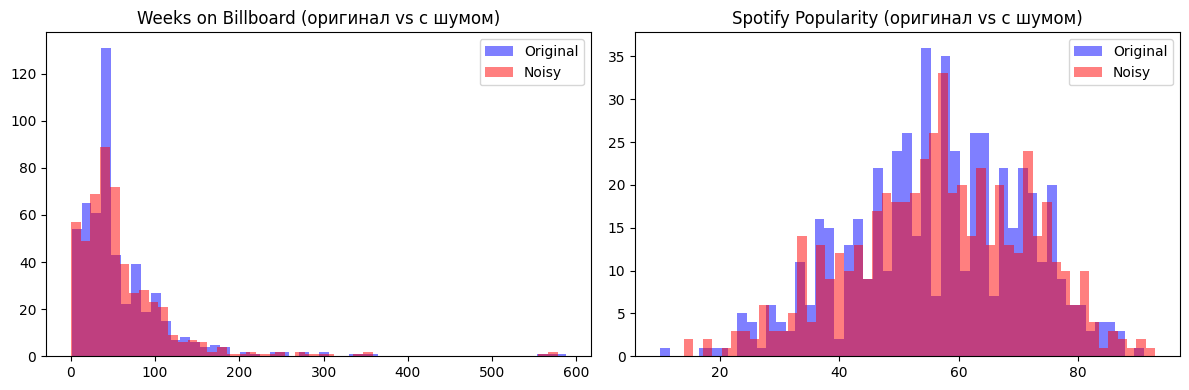

In [45]:
#1.2.9
np.random.seed(42)
df_clean['weeks_noisy'] = df_clean['weeks_on_billboard'] + np.random.normal(0, 10, len(df_clean))
df_clean['weeks_noisy'] = df_clean['weeks_noisy'].clip(lower=0)

df_clean['popularity_noisy'] = df_clean['spotify_popularity'] + np.random.normal(0, 3, len(df_clean))
df_clean['popularity_noisy'] = df_clean['popularity_noisy'].clip(0, 100)

print("Шум добавлен в 'weeks_on_billboard' (σ=10) и 'spotify_popularity' (σ=3)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['weeks_on_billboard'], bins=50, alpha=0.5, label='Original', color='blue')
axes[0].hist(df_clean['weeks_noisy'], bins=50, alpha=0.5, label='Noisy', color='red')
axes[0].set_title('Weeks on Billboard (оригинал vs с шумом)')
axes[0].legend()

axes[1].hist(df_clean['spotify_popularity'], bins=50, alpha=0.5, label='Original', color='blue')
axes[1].hist(df_clean['popularity_noisy'], bins=50, alpha=0.5, label='Noisy', color='red')
axes[1].set_title('Spotify Popularity (оригинал vs с шумом)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
#1.2.10
df_clean['decade'] = (df_clean['release_year'] // 10) * 10
print("Распределение альбомов по десятилетиям:")
print(df_clean['decade'].value_counts().sort_index())

def categorize_rank(rank):
    if rank <= 100:
        return 'Legendary'
    elif rank <= 250:
        return 'Iconic'
    elif rank <= 400:
        return 'Classic'
    else:
        return 'Notable'

df_clean['rank_category'] = df_clean['rank_2020'].apply(categorize_rank)
print("\nРаспределение категорий рейтинга:")
print(df_clean['rank_category'].value_counts())

def categorize_age(age):
    if age < 25:
        return 'Young'
    elif age < 35:
        return 'Prime'
    elif age < 50:
        return 'Mature'
    else:
        return 'Veteran'

df_clean['age_category'] = df_clean['ave_age_at_top_500'].apply(categorize_age)

Распределение альбомов по десятилетиям:
decade
1950     11
1960     80
1970    159
1980     84
1990    101
2000     63
2010     29
Name: count, dtype: int64

Распределение категорий рейтинга:
rank_category
Notable      213
Iconic       121
Classic      115
Legendary     78
Name: count, dtype: int64


In [47]:
#1.2.11
df_clean['genre_clean'] = df_clean['genre'].str.split(',').str[0].str.strip()
gender_map = {'Male': 'M', 'Female': 'F', 'Mixed': 'X', 'Unknown': 'U'}
df_clean['gender_code'] = df_clean['artist_gender'].map(gender_map)

print("Уникальные значения genre_clean:")
print(df_clean['genre_clean'].value_counts().head(10))

Уникальные значения genre_clean:
genre_clean
Punk/Post-Punk/New Wave/Power Pop      84
Soul/Gospel/R&B                        75
Blues/Blues Rock                       65
Hip-Hop/Rap                            61
Indie/Alternative Rock                 60
Country/Folk/Country Rock/Folk Rock    49
Singer-Songwriter/Heartland Rock       28
Hard Rock/Metal                        27
Funk/Disco                             22
Big Band/Jazz                          14
Name: count, dtype: int64


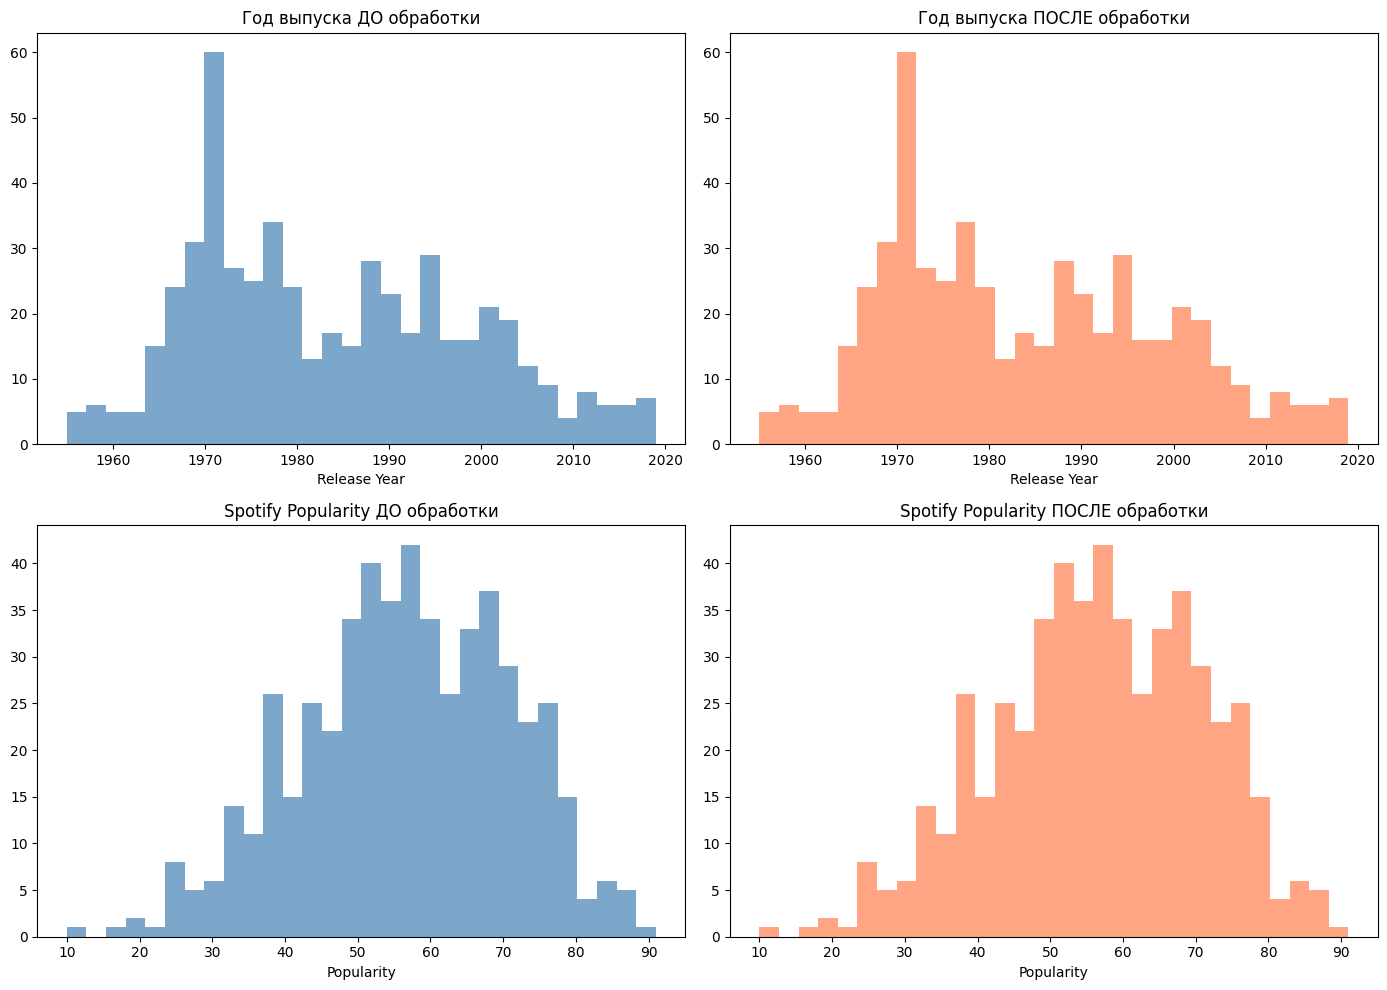

Сравнение ключевых метрик:
Средний release_year: 1983.8 → 1983.8
Средняя spotify_popularity: 56.6 → 56.6
Количество записей: 527 → 527


In [48]:
#1.2.12
original_df = df.copy()
original_clean = original_df.dropna(subset=['genre', 'release_year'])
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(original_clean['release_year'], bins=30, alpha=0.7, color='steelblue')
axes[0, 0].set_title('Год выпуска ДО обработки')
axes[0, 0].set_xlabel('Release Year')

axes[0, 1].hist(df_clean['release_year'], bins=30, alpha=0.7, color='coral')
axes[0, 1].set_title('Год выпуска ПОСЛЕ обработки')
axes[0, 1].set_xlabel('Release Year')

axes[1, 0].hist(original_clean['spotify_popularity'].dropna(), bins=30, alpha=0.7, color='steelblue')
axes[1, 0].set_title('Spotify Popularity ДО обработки')
axes[1, 0].set_xlabel('Popularity')

axes[1, 1].hist(df_clean['spotify_popularity'], bins=30, alpha=0.7, color='coral')
axes[1, 1].set_title('Spotify Popularity ПОСЛЕ обработки')
axes[1, 1].set_xlabel('Popularity')

plt.tight_layout()
plt.show()

print("Сравнение ключевых метрик:")
print(f"Средний release_year: {original_clean['release_year'].mean():.1f} → {df_clean['release_year'].mean():.1f}")
print(f"Средняя spotify_popularity: {original_clean['spotify_popularity'].mean():.1f} → {df_clean['spotify_popularity'].mean():.1f}")
print(f"Количество записей: {len(original_clean)} → {len(df_clean)}")

Топ-10 жанров по среднему рейтингу (меньше = лучше):
                                     Средний рейтинг  \
genre_clean                                            
Reggae                                         155.4   
Hip-Hop/Rap                                    204.8   
Hard Rock/Metal                                215.6   
Country/Folk/Country Rock/Folk Rock            223.4   
Singer-Songwriter/Heartland Rock               231.9   
Rock n' Roll/Rhythm & Blues                    243.2   
Big Band/Jazz                                  251.2   
Punk/Post-Punk/New Wave/Power Pop              253.8   
Blues/Blues ROck                               259.0   
Indie/Alternative Rock                         259.8   

                                     Средняя Spotify популярность  \
genre_clean                                                         
Reggae                                                       59.4   
Hip-Hop/Rap                                                  63.9  

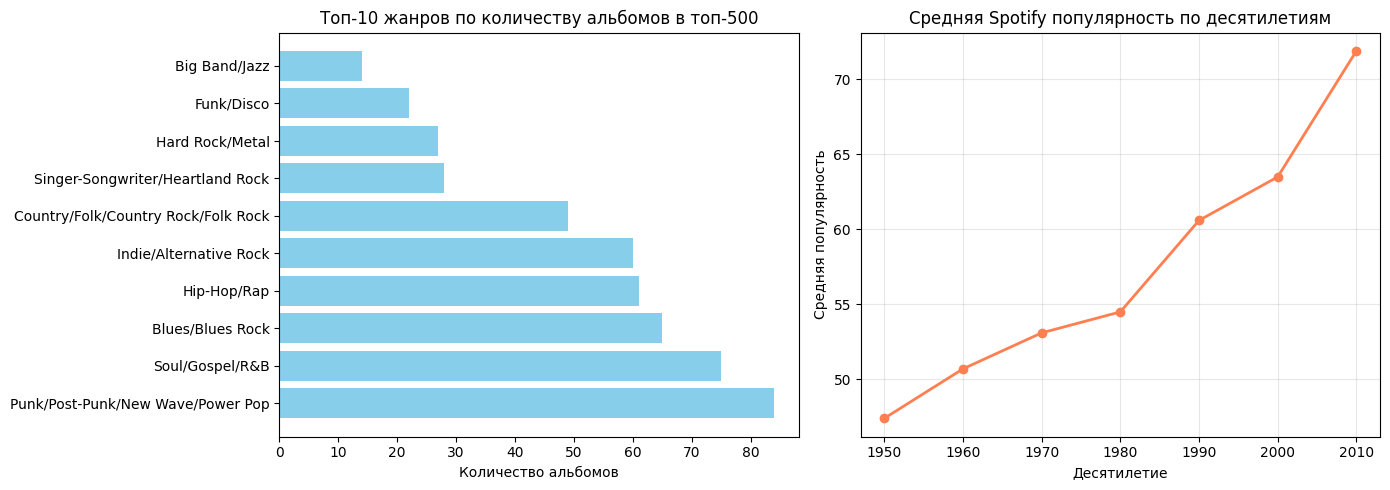

In [49]:
#1.2.13
genre_stats = df_clean.groupby('genre_clean').agg({
    'rank_2020': 'mean',
    'spotify_popularity': 'mean',
    'release_year': 'mean',
    'album': 'count'
}).round(1)
genre_stats.columns = ['Средний рейтинг', 'Средняя Spotify популярность', 'Средний год выпуска', 'Количество']
genre_stats = genre_stats.sort_values('Средний рейтинг')
print("Топ-10 жанров по среднему рейтингу (меньше = лучше):")
print(genre_stats.head(10))
decade_stats = df_clean.groupby('decade').agg({
    'rank_2020': 'median',
    'spotify_popularity': 'mean',
    'artist_member_count': 'mean'
}).round(1)
print("\nСтатистика по десятилетиям:")
print(decade_stats)
gender_stats = df_clean.groupby('gender_code').agg({
    'rank_2020': 'median',
    'spotify_popularity': 'mean',
    'artist_member_count': 'mean',
    'album': 'count'
}).round(1)
print("\nСтатистика по полу исполнителя:")
print(gender_stats)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_genres_count = genre_stats.nlargest(10, 'Количество')
axes[0].barh(top_genres_count.index, top_genres_count['Количество'], color='skyblue')
axes[0].set_title('Топ-10 жанров по количеству альбомов в топ-500')
axes[0].set_xlabel('Количество альбомов')

decade_stats_filtered = decade_stats.dropna().sort_index()
axes[1].plot(decade_stats_filtered.index, decade_stats_filtered['spotify_popularity'],
             marker='o', color='coral', linewidth=2)
axes[1].set_title('Средняя Spotify популярность по десятилетиям')
axes[1].set_xlabel('Десятилетие')
axes[1].set_ylabel('Средняя популярность')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
#1.3.1
categorical_features = ['genre_clean', 'type', 'artist_gender', 'rank_category', 'age_category', 'decade']

for col in categorical_features:
    if col in df_clean.columns:
        unique_values = df_clean[col].nunique()
        print(f"\n{col}:")
        print(f"  - Количество уникальных значений: {unique_values}")
        if unique_values <= 15:
            print(f"  - Значения: {df_clean[col].unique().tolist()}")
        else:
            print(f"  - Топ-10: {df_clean[col].value_counts().head(10).to_dict()}")


genre_clean:
  - Количество уникальных значений: 16
  - Топ-10: {'Punk/Post-Punk/New Wave/Power Pop': 84, 'Soul/Gospel/R&B': 75, 'Blues/Blues Rock': 65, 'Hip-Hop/Rap': 61, 'Indie/Alternative Rock': 60, 'Country/Folk/Country Rock/Folk Rock': 49, 'Singer-Songwriter/Heartland Rock': 28, 'Hard Rock/Metal': 27, 'Funk/Disco': 22, 'Big Band/Jazz': 14}

type:
  - Количество уникальных значений: 5
  - Значения: ['Studio', 'Compilation', 'Live', 'Greatest Hits', 'Soundtrack']

artist_gender:
  - Количество уникальных значений: 3
  - Значения: ['Male', 'Female', 'Male/Female', nan]

rank_category:
  - Количество уникальных значений: 4
  - Значения: ['Classic', 'Notable', 'Legendary', 'Iconic']

age_category:
  - Количество уникальных значений: 4
  - Значения: ['Mature', 'Prime', 'Young', 'Veteran']

decade:
  - Количество уникальных значений: 7
  - Значения: [1950, 2000, 1990, 2010, 1980, 1960, 1970]


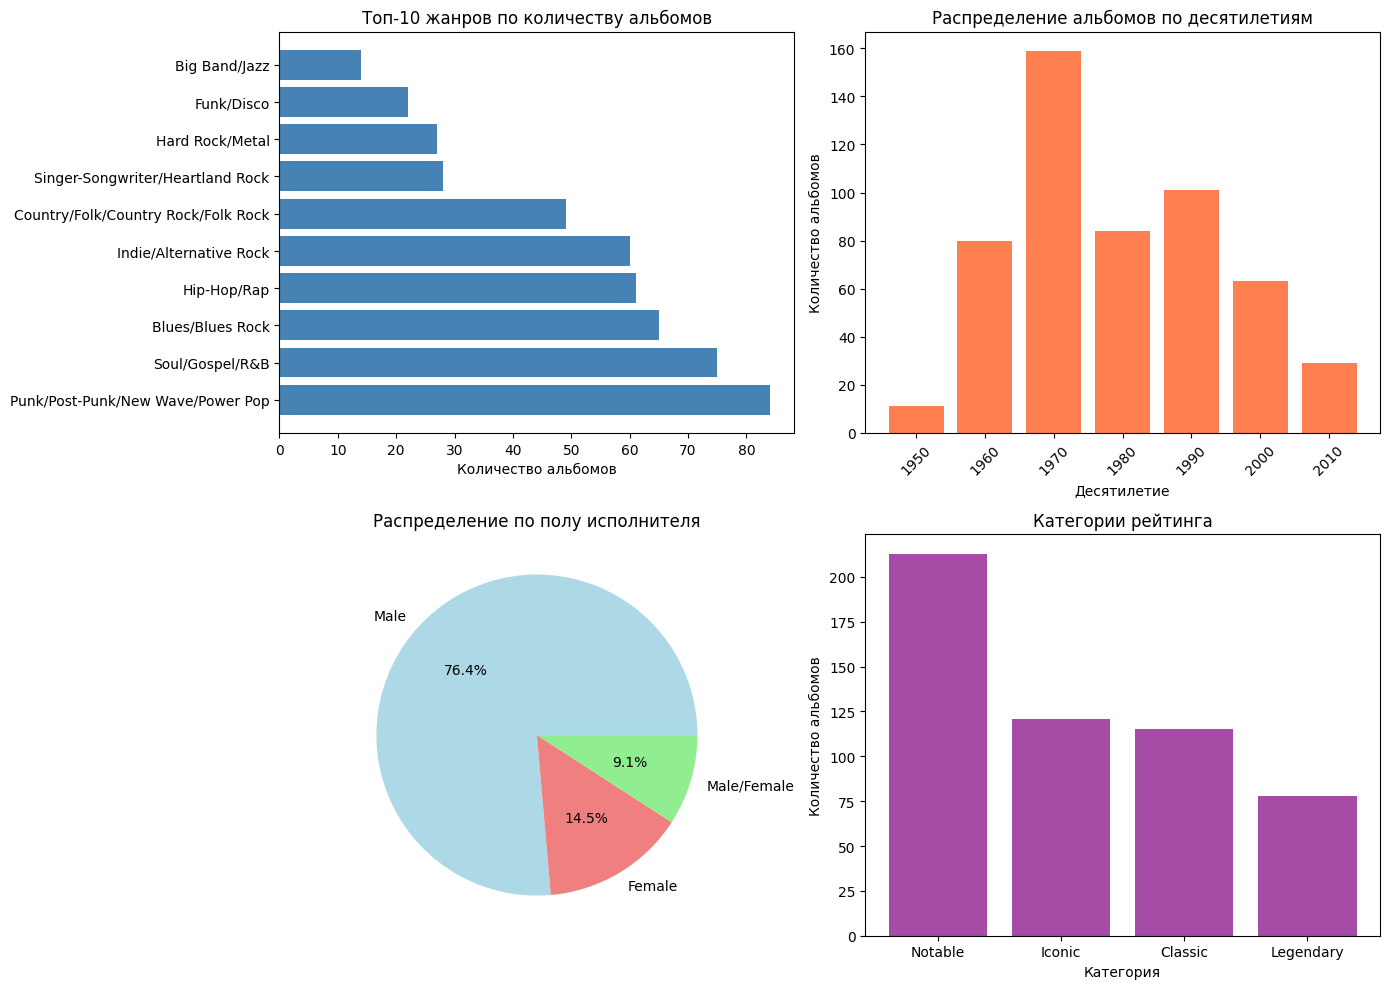

In [51]:
#1.3.2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_genres = df_clean['genre_clean'].value_counts().head(10)
axes[0, 0].barh(range(len(top_genres)), top_genres.values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_genres)))
axes[0, 0].set_yticklabels(top_genres.index)
axes[0, 0].set_title('Топ-10 жанров по количеству альбомов')
axes[0, 0].set_xlabel('Количество альбомов')

decade_counts = df_clean['decade'].value_counts().sort_index()
axes[0, 1].bar(decade_counts.index.astype(str), decade_counts.values, color='coral')
axes[0, 1].set_title('Распределение альбомов по десятилетиям')
axes[0, 1].set_xlabel('Десятилетие')
axes[0, 1].set_ylabel('Количество альбомов')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

gender_counts = df_clean['artist_gender'].value_counts()
axes[1, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
               colors=['lightblue', 'lightcoral', 'lightgreen'])
axes[1, 0].set_title('Распределение по полу исполнителя')

rank_cat_counts = df_clean['rank_category'].value_counts()
axes[1, 1].bar(rank_cat_counts.index, rank_cat_counts.values, color='purple', alpha=0.7)
axes[1, 1].set_title('Категории рейтинга')
axes[1, 1].set_xlabel('Категория')
axes[1, 1].set_ylabel('Количество альбомов')

plt.tight_layout()
plt.show()

In [52]:
#1.3.3
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le_genre = LabelEncoder()
df_clean['genre_code'] = le_genre.fit_transform(df_clean['genre_clean'])
print("Label Encoding для жанра (пример):")
print(df_clean[['genre_clean', 'genre_code']].drop_duplicates().head(10))

onehot = OneHotEncoder(sparse_output=False, drop='first')
rank_encoded = onehot.fit_transform(df_clean[['rank_category']])
rank_cat_df = pd.DataFrame(rank_encoded,
                           columns=[f'rank_{cat}' for cat in onehot.categories_[0][1:]])
df_clean = pd.concat([df_clean, rank_cat_df], axis=1)
print("\nOne-Hot Encoding для rank_category:")
print(rank_cat_df.head())

decade_freq = df_clean['decade'].value_counts(normalize=True)
df_clean['decade_frequency'] = df_clean['decade'].map(decade_freq)
print("\nЧастотное кодирование десятилетий (пример):")
print(df_clean[['decade', 'decade_frequency']].drop_duplicates().head(10))

Label Encoding для жанра (пример):
                            genre_clean  genre_code
0                         Big Band/Jazz           1
1           Rock n' Roll/Rhythm & Blues          13
4                       Soul/Gospel/R&B          15
10                          Hip-Hop/Rap           8
11                     Blues/Blues Rock           3
12  Country/Folk/Country Rock/Folk Rock           4
13               Indie/Alternative Rock           9
22    Punk/Post-Punk/New Wave/Power Pop          11
24                           Electronic           5
31                           Funk/Disco           6

One-Hot Encoding для rank_category:
   rank_Iconic  rank_Legendary  rank_Notable
0          0.0             0.0           0.0
1          0.0             0.0           1.0
2          0.0             0.0           0.0
3          0.0             0.0           1.0
4          0.0             1.0           0.0

Частотное кодирование десятилетий (пример):
    decade  decade_frequency
0     1950  

In [53]:
#1.3.4
genre_counts = df_clean['genre_clean'].value_counts()
print(f"Всего жанров: {len(genre_counts)}")
print(f"Жанров с < 5 альбомов: {(genre_counts < 5).sum()}")
print(f"Жанров с < 10 альбомов: {(genre_counts < 10).sum()}")

rare_genres = genre_counts[genre_counts < 5].index.tolist()
print(f"\nРедкие жанры (менее 5 альбомов): {rare_genres}")

df_clean['genre_grouped'] = df_clean['genre_clean'].apply(
    lambda x: 'Other' if x in rare_genres else x
)

print(f"\nПосле агрегации: {df_clean['genre_grouped'].nunique()} уникальных жанров")

genre_agg_stats = df_clean.groupby('genre_grouped')['rank_2020'].agg(['mean', 'median', 'count'])
genre_agg_stats = genre_agg_stats.sort_values('count', ascending=False)

print("\nТоп-10 жанров (после агрегации):")
print(genre_agg_stats.head(10))

Всего жанров: 16
Жанров с < 5 альбомов: 2
Жанров с < 10 альбомов: 4

Редкие жанры (менее 5 альбомов): ['Afrobeat', 'Blues/Blues ROck']

После агрегации: 15 уникальных жанров

Топ-10 жанров (после агрегации):
                                           mean  median  count
genre_grouped                                                 
Soul/Gospel/R&B                      264.784615   275.0     65
Punk/Post-Punk/New Wave/Power Pop    253.824561   260.0     57
Hip-Hop/Rap                          204.754386   192.0     57
Indie/Alternative Rock               259.808511   276.0     47
Country/Folk/Country Rock/Folk Rock  223.375000   211.0     40
Blues/Blues Rock                     267.678571   313.0     28
Funk/Disco                           280.315789   360.0     19
Hard Rock/Metal                      215.611111   227.5     18
Singer-Songwriter/Heartland Rock     231.866667   251.0     15
Electronic                           298.363636   241.0     11


Создана новая категория 'commercial_success':
commercial_success
Top 10 Hit          241
Moderate/Unknown    135
Top 50 Hit          100
Top 100 Hit          51
Name: count, dtype: int64

Медианный рейтинг Rolling Stone по категориям коммерческого успеха:
commercial_success
Top 100 Hit         207.5
Top 10 Hit          212.0
Top 50 Hit          246.0
Moderate/Unknown    308.0
Name: rank_2020, dtype: float64


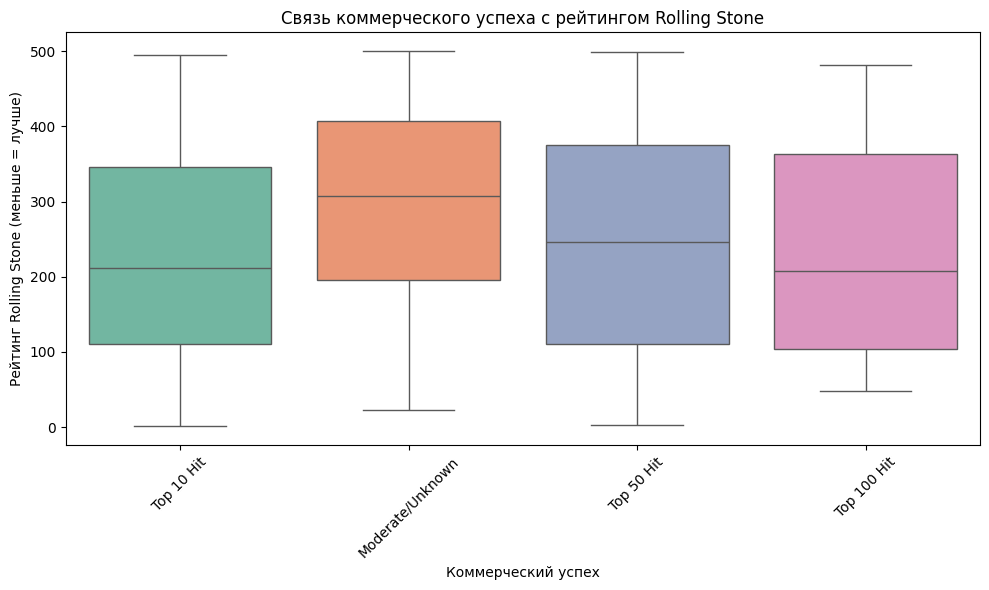

In [54]:
#1.3.5
def categorize_success(row):
    if pd.notna(row['peak_billboard_position']) and row['peak_billboard_position'] <= 10:
        return 'Top 10 Hit'
    elif pd.notna(row['peak_billboard_position']) and row['peak_billboard_position'] <= 50:
        return 'Top 50 Hit'
    elif pd.notna(row['peak_billboard_position']) and row['peak_billboard_position'] <= 100:
        return 'Top 100 Hit'
    else:
        return 'Moderate/Unknown'

df_clean['commercial_success'] = df_clean.apply(categorize_success, axis=1)

print("Создана новая категория 'commercial_success':")
print(df_clean['commercial_success'].value_counts())

success_rank = df_clean.groupby('commercial_success')['rank_2020'].median()
print("\nМедианный рейтинг Rolling Stone по категориям коммерческого успеха:")
print(success_rank.sort_values())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='commercial_success', y='rank_2020',
            hue='commercial_success', legend=False, palette='Set2')
plt.title('Связь коммерческого успеха с рейтингом Rolling Stone')
plt.xlabel('Коммерческий успех')
plt.ylabel('Рейтинг Rolling Stone (меньше = лучше)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()